## <center>Reducci&oacute;n de dimensionalidad</center>

### PCA - Análisis de Componentes Principales

Procedimiento matemático por el cual se transforma un conjunto de variables correlacionadas en un conjunto de variables no correlacionadas de menor dimensión. Estas nuevas variables se obtiene a partir de combinaciones lineales de las variables originales. <br>
Estas nuevas variables son las que se denominan Componentes Principales

Esta técnica intenta hallar aquellas combinaciones lineales de las variables originales que maximizan la varianza (minimizan la pérdida de información original)

Esta técnica no requiere supuestos por lo que puede aplicarse siempre (pero, ojo!, tendrá sentido si las variables originales están correlacionadas)

Se explora la existencia de variables latentes

El objetivo es reducir la dimensión del problema, es decir, descartar la información redundante



![pca.png](attachment:pca.png)

Uno de los planteos realizados para resolver este problema, lo realizó Hotelling. <br>
Buscó la combinanción lineal de las variables que maximiza la variabilidad

https://www.cis.rit.edu/~rlepci/Erho/Derek/Useful_References/Principal%20Components%20Analysis/Hotelling_PCA_part2.pdf

$ \textbf{Matemática detrás de los Componentes Principales (PCA):}$

Dados los datos centrados $ X = \{ x^{(i)} \}_{i=1}^{m} $, donde $ x^{(i)} \in \mathbb{R}^n $, los componentes principales $ z^{(i)} $ se obtienen como combinaciones lineales de las variables originales que maximizan la varianza:

1. **Componentes Principales:**

   Los componentes principales $ z^{(i)} $ se definen como:

   $ z^{(i)} = u^{(i)T} (x^{(i)} - \bar{x}) $

   donde $ u^{(i)} $ es el i-ésimo autovector de la matriz de covarianza $ \Sigma $ de $ X $, y $ \bar{x} $ es el vector de medias de $ X $.

2. **Carga (Loadings):**

   Las cargas de los componentes principales representan las contribuciones de cada variable original $ x^{(j)} $ en el cálculo de los componentes principales $ z^{(i)} $. Estas cargas están dadas por los elementos del autovector correspondiente $ u^{(i)} $:

   $ \text{Carga para } x^{(j)} \text{ en } z^{(i)}: \quad \text{Carga}_{ij} = u_j^{(i)} $

   $ u_j^{(i)} $ es el elemento $ j $-ésimo del autovector $ u^{(i)} $.

En resumen, los componentes principales se calculan proyectando los datos originales sobre los autovectores de la matriz de covarianza, y las cargas indican cómo cada variable contribuye a cada componente principal.


Proponción de la variabilidad que capta cada componente principal

$$\text{Variabilidad explicada por el i-ésimo componente principal: } \frac{\lambda^{(i)}}{\sum_{j=1}^{n} \lambda^{(j)}}$$

Siendo $\lambda^{(i)}$ el autovalor asociado al autovector i, correspondiente a la componente $z^{(i)}$

In [ ]:
from sklearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### Ejemplo 1

Dataset sintético

**Paso a paso**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un dataset sintético
np.random.seed(0)
n_samples = 100

# Generar datos correlacionados
X1 = np.random.normal(loc=0, scale=1, size=n_samples)
X2 = 2 * X1 + np.random.normal(loc=0, scale=1, size=n_samples)  # X2 es correlacionado con X1
X3 = -0.5 * X1 + 0.5 * X2 + np.random.normal(loc=0, scale=1, size=n_samples)  # X3 es correlacionado con X1 y X2

# Crear un DataFrame
data = pd.DataFrame({'Feature1': X1, 'Feature2': X2, 'Feature3': X3})
print(data.head())

   Feature1  Feature2  Feature3
0  1.764052  5.411255  1.454420
1  0.400157 -0.547445 -0.713180
2  0.978738  0.686991  0.953786
3  2.240893  5.451183  2.260409
4  1.867558  2.561993  0.987349


In [ ]:
# Normalizar los datos
def normalize_data(df):
    return (df - df.mean()) / df.std()

data_normalized = normalize_data(data)
print(data_normalized.head())

   Feature1  Feature2  Feature3
0  1.682440  2.190454  1.129803
1  0.335995 -0.314958 -0.567632
2  0.907173  0.204077  0.737759
3  2.153180  2.207242  1.760968
4  1.784622  0.992445  0.764042


Matriz de Correlación
          Feature1  Feature2  Feature3
Feature1  1.000000  0.900675  0.499144
Feature2  0.900675  1.000000  0.640939
Feature3  0.499144  0.640939  1.000000


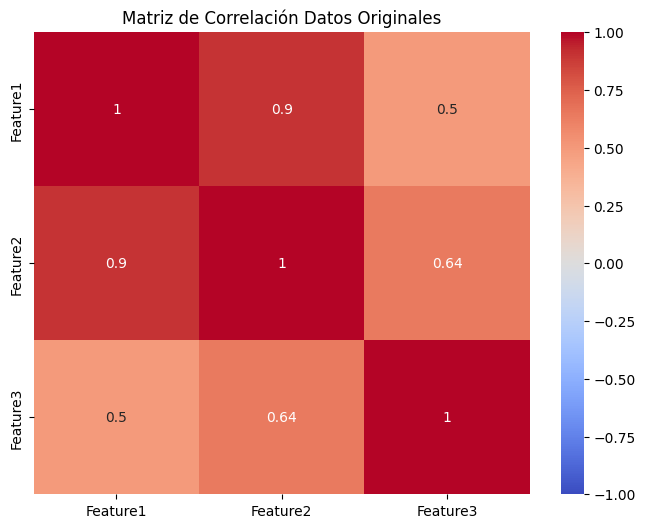

In [ ]:
# Calcular la matriz de correlacion
corr_matrix = data.corr()
print("Matriz de Correlación")
print(corr_matrix)

# Visualizar la matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación Datos Originales')
plt.show()

Matriz de Covarianza:
          Feature1  Feature2  Feature3
Feature1  1.000000  0.900675  0.499144
Feature2  0.900675  1.000000  0.640939
Feature3  0.499144  0.640939  1.000000


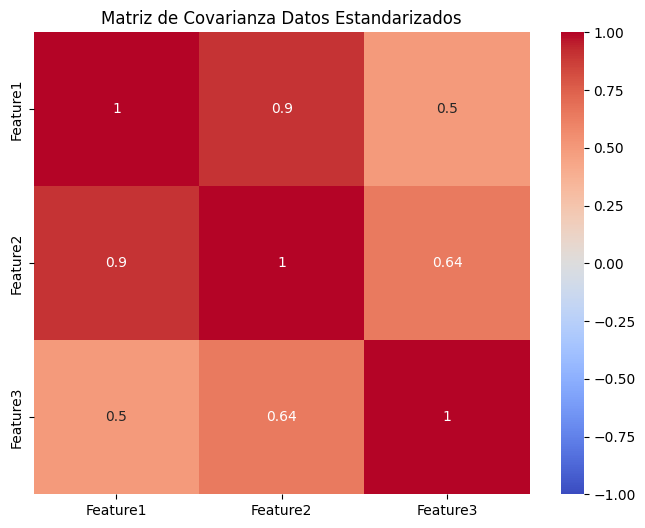

In [ ]:
# Calcular la matriz de covarianza
cov_matrix = data_normalized.cov()
print("Matriz de Covarianza:")
print(cov_matrix)

# Visualizar la matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Covarianza Datos Estandarizados')
plt.show()

In [ ]:
# Calcular los valores y vectores propios
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Ordenar los vectores propios por valor propio en orden descendente
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[sorted_indices]
eigenvectors_sorted = eigenvectors[:, sorted_indices]

print("Valores propios:")
print(eigenvalues_sorted)
print("Vectores propios:")
print(eigenvectors_sorted)

# Seleccionar los primeros dos componentes principales
pc1 = eigenvectors_sorted[:, 0]
pc2 = eigenvectors_sorted[:, 1]

Valores propios:
[2.37488836 0.5436952  0.08141644]
Vectores propios:
[[-0.59353439 -0.48920271 -0.63905996]
 [-0.62511999 -0.2198907   0.7489146 ]
 [-0.50689439  0.84399573 -0.1752977 ]]


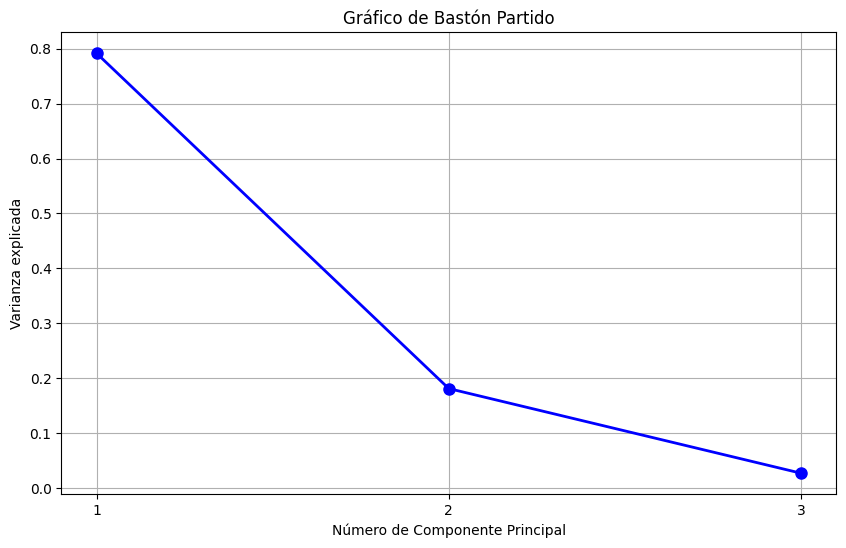

In [ ]:
# Crear el gráfico de bastón partido
plt.figure(figsize=(10, 6))
var_exp=eigenvalues_sorted/sum(eigenvalues_sorted)
plt.plot(range(1, len(eigenvalues_sorted) + 1), var_exp, 'bo-', markersize=8, linewidth=2)
plt.title('Gráfico de Bastón Partido')
plt.xlabel('Número de Componente Principal')
plt.ylabel('Varianza explicada')
plt.grid(True)
plt.xticks(range(1, len(eigenvalues) + 1))
plt.show()

Utilizamos los vectores propios para transformar los datos a la nueva base definida por los componentes principales.

   Principal Component 1  Principal Component 2
0              -2.940573              -0.351166
1               0.285192              -0.574193
2              -1.039977               0.134000
3              -3.550403              -0.052444
4              -2.066920              -0.446423


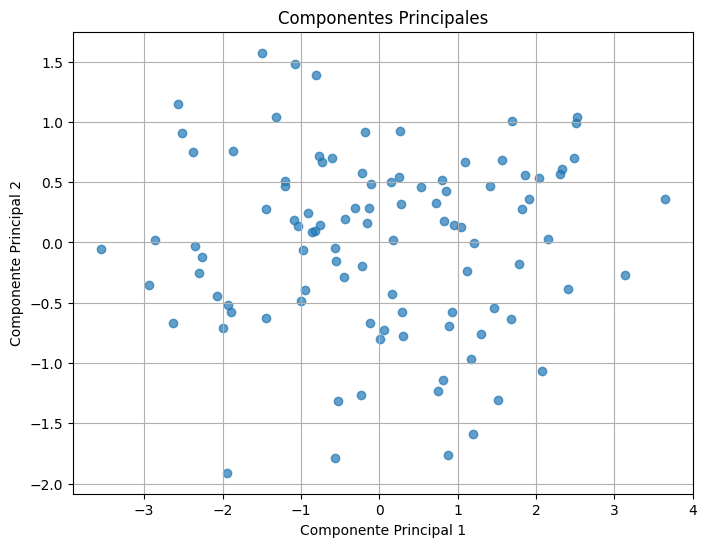

Varianza explicada por cada componente: [0.79162945 0.18123173]
Varianza total explicada: 0.9728611853790453


In [ ]:
# Transformar los datos
data_pca = np.dot(data_normalized, eigenvectors_sorted[:, :2])

# Crear un DataFrame con los componentes principales
pc_df = pd.DataFrame(data=data_pca, columns=['Principal Component 1', 'Principal Component 2'])
print(pc_df.head())

# Visualizar los componentes principales
plt.figure(figsize=(8, 6))
plt.scatter(pc_df['Principal Component 1'], pc_df['Principal Component 2'], alpha=0.7)
plt.title('Componentes Principales')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

# Explicación de la varianza
explained_variance = eigenvalues_sorted / np.sum(eigenvalues_sorted)
print(f"Varianza explicada por cada componente: {explained_variance[:2]}")
print(f"Varianza total explicada: {explained_variance[:2].sum()}")

**Ahora utilizando la librería sklearn**

In [ ]:
from sklearn.decomposition import PCA as sklearnPCA

# Aplicar PCA usando sklearn
pca = sklearnPCA(n_components=3)
data_pca_sklearn = pca.fit_transform(data_normalized)
pc_df_sklearn = pd.DataFrame(data=data_pca_sklearn, columns=['Principal Component 1', 'Principal Component 2','Principal Component 3'])
print("Componentes Principales (sklearn):")
print(pc_df_sklearn.head())

# Explicación de la varianza
explained_variance_sklearn = pca.explained_variance_ratio_
print(f"Varianza explicada por cada componente (sklearn): {explained_variance_sklearn}")
print(f"Varianza total explicada (sklearn): {explained_variance_sklearn.sum()}")

Componentes Principales (sklearn):
   Principal Component 1  Principal Component 2  Principal Component 3
0              -2.940573               0.351166               0.367231
1               0.285192               0.574193              -0.351092
2              -1.039977              -0.134000              -0.556230
3              -3.550403               0.052444              -0.031669
4              -2.066920               0.446423              -0.531158
Varianza explicada por cada componente (sklearn): [0.79162945 0.18123173 0.02713881]
Varianza total explicada (sklearn): 1.0


Los componentes principales en las dos versiones pueden diferir en signo. No afecta la validez del análisis, ya que el signo de los componentes principales no tiene un significado en la interpretación de los datos.

### Ejemplo 2

#### Dataset Iris

In [ ]:
iris=datasets.load_iris()

iris_modif=(np.column_stack(iris['data'])).tolist()
iris_modif.append(iris['target'].tolist())

In [ ]:
df_iris=pd.DataFrame(iris_modif).T
nombres_columnas=['sepal_length','sepal_width','petal_length','petal_width','target']
df_iris.columns=nombres_columnas

In [ ]:
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [ ]:
from sklearn.preprocessing import StandardScaler

columnas_elegidas = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

x = df_iris.loc[:, columnas_elegidas].values

y = df_iris.loc[:,['target']].values

x = StandardScaler().fit_transform(x)

In [ ]:
from sklearn.decomposition import PCA

pca_iris = PCA()
x_transformada = pca_iris.fit_transform(x)

In [ ]:
explained_variance_sklearn = pca_iris.explained_variance_ratio_
print(f"Varianza explicada por cada componente (sklearn): {explained_variance_sklearn}")

Varianza explicada por cada componente (sklearn): [0.72962445 0.22850762 0.03668922 0.00517871]


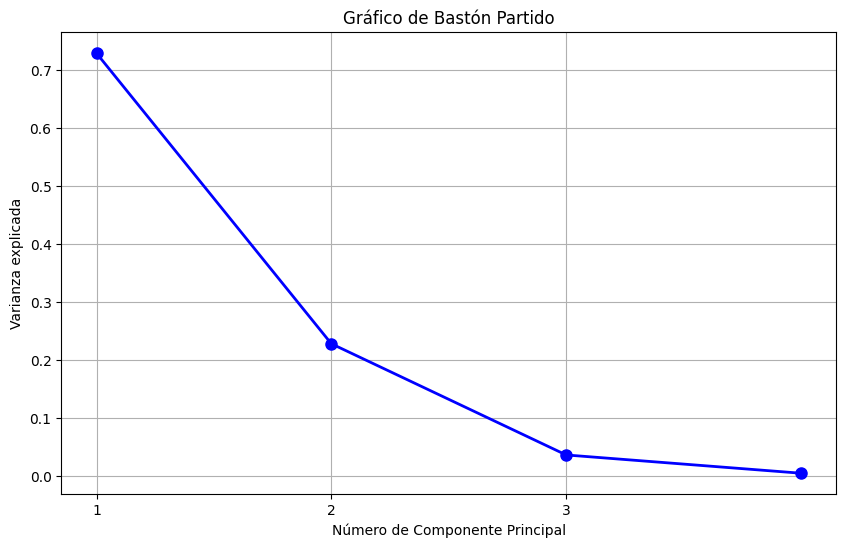

In [ ]:
# Crear el gráfico de bastón partido
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_sklearn) + 1), explained_variance_sklearn, 'bo-', markersize=8, linewidth=2)
plt.title('Gráfico de Bastón Partido')
plt.xlabel('Número de Componente Principal')
plt.ylabel('Varianza explicada')
plt.grid(True)
plt.xticks(range(1, len(eigenvalues) + 1))
plt.show()

In [ ]:
pca_df_aux=pd.DataFrame(data = x_transformada)[[0,1]]
pca_df_aux.columns=['cp_1', 'cp_2']

pca_df_aux.head()

,cp_1,cp_2
0,-2.264703,0.480027
1,-2.080961,-0.674134
2,-2.364229,-0.341908
3,-2.299384,-0.597395
4,-2.389842,0.646835


In [ ]:
pca_df = pd.concat([pca_df_aux, df_iris[['target']]], axis = 1)

In [ ]:
pca_df.head()

,cp_1,cp_2,target
0,-2.264703,0.480027,0.0
1,-2.080961,-0.674134,0.0
2,-2.364229,-0.341908,0.0
3,-2.299384,-0.597395,0.0
4,-2.389842,0.646835,0.0


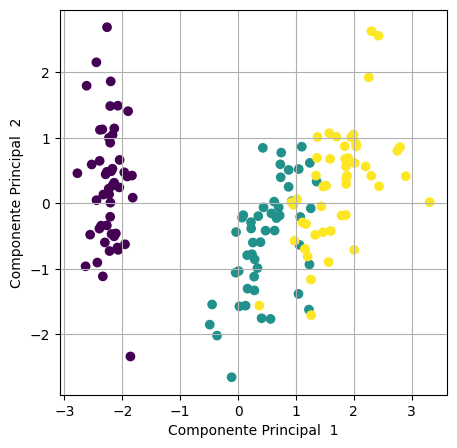

In [ ]:
targets = ['Setosa', 'Versicolor', 'Virginica']
fig = plt.figure(figsize = (5,5))
ax= fig.add_subplot(1,1,1)

ax.scatter(x=pca_df['cp_1'],y=pca_df['cp_2'],c=pca_df['target'])
ax.set_xlabel('Componente Principal  1', fontsize = 10)
ax.set_ylabel('Componente Principal  2', fontsize = 10)
ax.grid()

plt.show()